What countries or regions rank the highest in overall happiness and each of the six factors contributing to happiness?

How did country ranks or scores change between the 2015 and 2016 as well as the 2016 and 2017 reports?

Did any country experience a significant increase or decrease in happiness?

In [4]:
import pandas as pd
import numpy as np

# Load the dataframes for each year
df_2015 = pd.read_csv("2015.csv")
df_2016 = pd.read_csv("2016.csv")
df_2017 = pd.read_csv("2017.csv")
df_2018 = pd.read_csv("2018.csv")
df_2019 = pd.read_csv("2019.csv")

# comprehensive mapping dictionary
column_mapping = {
    # Country/Region names
    'Country': 'country',
    'Country or region': 'country',
    'Region': 'region',

    # Rank/Score names
    'Happiness Rank': 'rank',
    'Happiness.Rank': 'rank',
    'Overall rank': 'rank',
    'Happiness Score': 'score',
    'Happiness.Score': 'score',
    'Score': 'score',

    # Factor names
    'Economy (GDP per Capita)': 'gdp_per_capita',
    'Economy..GDP.per.Capita.': 'gdp_per_capita',
    'GDP per capita': 'gdp_per_capita',

    'Family': 'social_support',
    'Social support': 'social_support',

    'Health (Life Expectancy)': 'healthy_life_expectancy',
    'Health..Life.Expectancy.': 'healthy_life_expectancy',
    'Healthy life expectancy': 'healthy_life_expectancy',

    'Freedom': 'freedom',
    'Freedom to make life choices': 'freedom',

    'Trust (Government Corruption)': 'perceptions_of_corruption',
    'Trust..Government.Corruption.': 'perceptions_of_corruption',
    'Perceptions of corruption': 'perceptions_of_corruption',

    'Generosity': 'generosity',

    'Dystopia Residual': 'dystopia_residual',
    'Dystopia.Residual': 'dystopia_residual'
}

# List of columns we want in our final dataset
desired_columns = ['country', 'region', 'year', 'rank', 'score', 'gdp_per_capita',
                   'social_support', 'healthy_life_expectancy', 'freedom',
                   'perceptions_of_corruption', 'generosity', 'dystopia_residual']

def clean_dataframe(df, year):
    """Clean and standardize a single year's dataframe"""
    # copy to avoid modifying the original
    df_clean = df.copy()

    # Rename columns using the mapping (only for columns that exist)
    df_clean = df_clean.rename(columns={k: v for k, v in column_mapping.items()
                                       if k in df_clean.columns})

    # Adding year column
    df_clean['year'] = year

    # Ensuring all desired columns exist (add missing ones as NaN)
    for col in desired_columns:
        if col not in df_clean.columns:
            df_clean[col] = np.nan

    # Returning only the desired columns in consistent order
    return df_clean[desired_columns]

#  cleaning each dataframe
dfs_clean = []
for year, df in zip([2015, 2016, 2017, 2018, 2019],
                    [df_2015, df_2016, df_2017, df_2018, df_2019]):
    dfs_clean.append(clean_dataframe(df, year))

# Concatenating all dataframes
df_combined = pd.concat(dfs_clean, ignore_index=True)

# Handling region mapping (since region is only in 2015-2016)
region_map = df_combined[df_combined['region'].notna()][['country', 'region']].drop_duplicates()
df_combined = df_combined.drop('region', axis=1)  # Removes the incomplete region column
df_combined = pd.merge(df_combined, region_map, on='country', how='left')

# Save the combined dataframe to a CSV file
df_combined.to_csv('combined_happiness_data.csv', index=False)
print("Combined data exported to combined_happiness_data.csv")

Combined data exported to combined_happiness_data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_2015=pd.read_csv("2015.csv")
df_2016=pd.read_csv("2016.csv")
df_2017=pd.read_csv("2017.csv")
df_2018=pd.read_csv("2018.csv")
df_2019=pd.read_csv("2019.csv")

In [ ]:
print("2015 Columns:", df_2015.columns.tolist())
print("2016 Columns:", df_2016.columns.tolist())
print("2017 Columns:", df_2017.columns.tolist())
print("2018 Columns:", df_2018.columns.tolist())
print("2019 Columns:", df_2019.columns.tolist())

2015 Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2016 Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2017 Columns: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']
2018 Columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
2019 Columns: ['Overall rank', 'Country or region'

# **Data** **Cleaning**

In [ ]:

# comprehensive mapping dictionary
column_mapping = {
    # Country/Region names
    'Country': 'country',
    'Country or region': 'country',
    'Region': 'region',

    # Rank/Score names
    'Happiness Rank': 'rank',
    'Happiness.Rank': 'rank',
    'Overall rank': 'rank',
    'Happiness Score': 'score',
    'Happiness.Score': 'score',
    'Score': 'score',

    # Factor names
    'Economy (GDP per Capita)': 'gdp_per_capita',
    'Economy..GDP.per.Capita.': 'gdp_per_capita',
    'GDP per capita': 'gdp_per_capita',

    'Family': 'social_support',
    'Social support': 'social_support',

    'Health (Life Expectancy)': 'healthy_life_expectancy',
    'Health..Life.Expectancy.': 'healthy_life_expectancy',
    'Healthy life expectancy': 'healthy_life_expectancy',

    'Freedom': 'freedom',
    'Freedom to make life choices': 'freedom',

    'Trust (Government Corruption)': 'perceptions_of_corruption',
    'Trust..Government.Corruption.': 'perceptions_of_corruption',
    'Perceptions of corruption': 'perceptions_of_corruption',

    'Generosity': 'generosity',

    'Dystopia Residual': 'dystopia_residual',
    'Dystopia.Residual': 'dystopia_residual'
}

# List of columns we want in our final dataset
desired_columns = ['country', 'region', 'year', 'rank', 'score', 'gdp_per_capita',
                   'social_support', 'healthy_life_expectancy', 'freedom',
                   'perceptions_of_corruption', 'generosity', 'dystopia_residual']

def clean_dataframe(df, year):
    """Clean and standardize a single year's dataframe"""
    # copy to avoid modifying the original
    df_clean = df.copy()

    # Rename columns using the mapping (only for columns that exist)
    df_clean = df_clean.rename(columns={k: v for k, v in column_mapping.items()
                                       if k in df_clean.columns})

    # Adding year column
    df_clean['year'] = year

    # Ensuring all desired columns exist (add missing ones as NaN)
    for col in desired_columns:
        if col not in df_clean.columns:
            df_clean[col] = np.nan

    # Returning only the desired columns in consistent order
    return df_clean[desired_columns]

#  cleaning each dataframe
dfs_clean = []
for year, df in zip([2015, 2016, 2017, 2018, 2019],
                    [df_2015, df_2016, df_2017, df_2018, df_2019]):
    dfs_clean.append(clean_dataframe(df, year))

# Concatenating all dataframes
df_combined = pd.concat(dfs_clean, ignore_index=True)

# Handling region mapping (since region is only in 2015-2016)
region_map = df_combined[df_combined['region'].notna()][['country', 'region']].drop_duplicates()
df_combined = df_combined.drop('region', axis=1)  # Removes the incomplete region column
df_combined = pd.merge(df_combined, region_map, on='country', how='left')

print("Combined DataFrame shape:", df_combined.shape)
print(df_combined.head())

Combined DataFrame shape: (782, 12)
       country  year  rank  score  gdp_per_capita  social_support  \
0  Switzerland  2015     1  7.587         1.39651         1.34951   
1      Iceland  2015     2  7.561         1.30232         1.40223   
2      Denmark  2015     3  7.527         1.32548         1.36058   
3       Norway  2015     4  7.522         1.45900         1.33095   
4       Canada  2015     5  7.427         1.32629         1.32261   

   healthy_life_expectancy  freedom  perceptions_of_corruption  generosity  \
0                  0.94143  0.66557                    0.41978     0.29678   
1                  0.94784  0.62877                    0.14145     0.43630   
2                  0.87464  0.64938                    0.48357     0.34139   
3                  0.88521  0.66973                    0.36503     0.34699   
4                  0.90563  0.63297                    0.32957     0.45811   

   dystopia_residual          region  
0            2.51738  Western Europe  
1 

# **EDA**

In [ ]:
# Gets statistical summary for numerical columns
numerical_columns = ['score', 'gdp_per_capita', 'social_support',
                     'healthy_life_expectancy', 'freedom',
                     'perceptions_of_corruption', 'generosity']

print("Statistical Summary:")
print(df_combined[numerical_columns].describe())


Statistical Summary:
            score  gdp_per_capita  social_support  healthy_life_expectancy  \
count  782.000000      782.000000      782.000000               782.000000   
mean     5.379018        0.916047        1.078392                 0.612416   
std      1.127456        0.407340        0.329548                 0.248309   
min      2.693000        0.000000        0.000000                 0.000000   
25%      4.509750        0.606500        0.869363                 0.440183   
50%      5.322000        0.982205        1.124735                 0.647310   
75%      6.189500        1.236187        1.327250                 0.808000   
max      7.769000        2.096000        1.644000                 1.141000   

          freedom  perceptions_of_corruption  generosity  
count  782.000000                 781.000000  782.000000  
mean     0.411091                   0.125436    0.218576  
std      0.152880                   0.105816    0.122321  
min      0.000000                   0.00

**Score**

1.The average global happiness score is 5.38

2.There is a wide variation between the most happy countries and least happy countries(2.69 to 7.77)

3.Relatively symmetric distribution (mean ≈ median ≈ 5.32)

**GDP per Capita**

1.The average contribution is 0.92 which means it is a very important factor especially to the top 15%

2.The data is slightly skewed(mean=0.92&median=0.98)

**Social Support**

1.Average contribution is 1.08 which is very high

2.The data is relatively symmetric

 **Healthy Life Expectancy**

1.Average contribution is o.61 which is moderate

2.It is a very important factor for the top 15%

**Freedom**

1.Moderate freedom levels globally

2.Range: 0.00 to 0.72 - Wide variation in freedom perceptions

3.Slightly left-skewed (mean < median)

**Perceptions of Corruption**

1.People really don't care about corruption(mean=0.13)

2.The data is skewed

3.Missing value

**Generosity**

1.Relatively has a low influence on happiness

2.A few people consider it highly(max=0.84)

In [ ]:
# Get the top 10 countries by average happiness score
top_countries = df_combined.groupby('country')['score'].mean().sort_values(ascending=False).head(10)
print("Top 10 Countries by Average Happiness Score (2015-2019):")
print(top_countries)

# Get the top countries for each factor
factors = ['gdp_per_capita', 'social_support', 'healthy_life_expectancy',
           'freedom', 'generosity', 'perceptions_of_corruption']

top_countries_by_factor = {}
for factor in factors:
    top_countries_by_factor[factor] = df_combined.groupby('country')[factor].mean().sort_values(ascending=False).head(5)

print("Top Countries by Each Factor:")
for factor, countries in top_countries_by_factor.items():
    print(f"{factor}:")
    print(countries)

Top 10 Countries by Average Happiness Score (2015-2019):
country
Denmark        7.5460
Norway         7.5410
Finland        7.5378
Switzerland    7.5114
Iceland        7.5110
Netherlands    7.4046
Canada         7.3506
Sweden         7.3192
New Zealand    7.3130
Australia      7.2762
Name: score, dtype: float64
Top Countries by Each Factor:
gdp_per_capita:
country
Qatar                   1.743691
United Arab Emirates    1.645227
Luxembourg              1.637675
Singapore               1.592138
Kuwait                  1.555662
Name: gdp_per_capita, dtype: float64
social_support:
country
Iceland              1.492813
Trinidad & Tobago    1.484500
Denmark              1.447688
Ireland              1.445056
New Zealand          1.439729
Name: social_support, dtype: float64
healthy_life_expectancy:
country
Hong Kong          1.029513
Singapore          1.014186
Japan              0.979099
Northern Cyprus    0.975500
Spain              0.950108
Name: healthy_life_expectancy, dtype: float64
f

In [ ]:
def calculate_year_changes(year1, year2, df1, df2):
    """Calculate rank and score changes between two years"""
    df1_clean = clean_dataframe(df1, year1)
    df2_clean = clean_dataframe(df2, year2)

    # Merge data for the two years
    merged = pd.merge(df1_clean[['country', 'rank', 'score']],
                     df2_clean[['country', 'rank', 'score']],
                     on='country', suffixes=(f'_{year1}', f'_{year2}'))

    # Calculate changes
    merged['rank_change'] = merged[f'rank_{year1}'] - merged[f'rank_{year2}']  # Positive means improvement
    merged['score_change'] = merged[f'score_{year2}'] - merged[f'score_{year1}']

    return merged

In [ ]:
changes_15_16 = calculate_year_changes(2015, 2016, df_2015, df_2016)

# Get top improvements and declines
top_rank_improvements = changes_15_16.nlargest(10, 'rank_change')
top_score_improvements = changes_15_16.nlargest(10, 'score_change')

print("Top 10 Rank Improvements (2015-2016):")
print(top_rank_improvements[['country', 'rank_2015', 'rank_2016', 'rank_change']])

Top 10 Rank Improvements (2015-2016):
       country  rank_2015  rank_2016  rank_change
66     Algeria         68         38           30
87      Latvia         89         68           21
126   Cameroon        133        114           19
84     Romania         86         71           15
125  Sri Lanka        132        117           15
128      Egypt        135        120           15
59    Malaysia         61         47           14
115      Nepal        121        107           14
135    Senegal        142        128           14
98     Hungary        104         91           13


# **Visualizations**

COUNTRIES WITH SIGNIFICANT HAPPINESS CHANGES (2015-2019)
Countries with Largest Happiness Improvements (2015-2019):
-------------------------------------------------------
Benin: +1.543 points (from 3.340 to 4.883)
Ivory Coast: +1.289 points (from 3.655 to 4.944)
Togo: +1.246 points (from 2.839 to 4.085)
Honduras: +1.072 points (from 4.788 to 5.860)
Burkina Faso: +1.000 points (from 3.587 to 4.587)
Hungary: +0.958 points (from 4.800 to 5.758)
Romania: +0.946 points (from 5.124 to 6.070)
Gabon: +0.903 points (from 3.896 to 4.799)
Cambodia: +0.881 points (from 3.819 to 4.700)
Guinea: +0.878 points (from 3.656 to 4.534)
Countries with Largest Happiness Declines (2015-2019):
--------------------------------------------------
Venezuela: -2.103 points (from 6.810 to 4.707)
Lesotho: -1.096 points (from 4.898 to 3.802)
Zambia: -1.022 points (from 5.129 to 4.107)
Zimbabwe: -0.947 points (from 4.610 to 3.663)
Haiti: -0.921 points (from 4.518 to 3.597)
Malawi: -0.882 points (from 4.292 to 3.410)


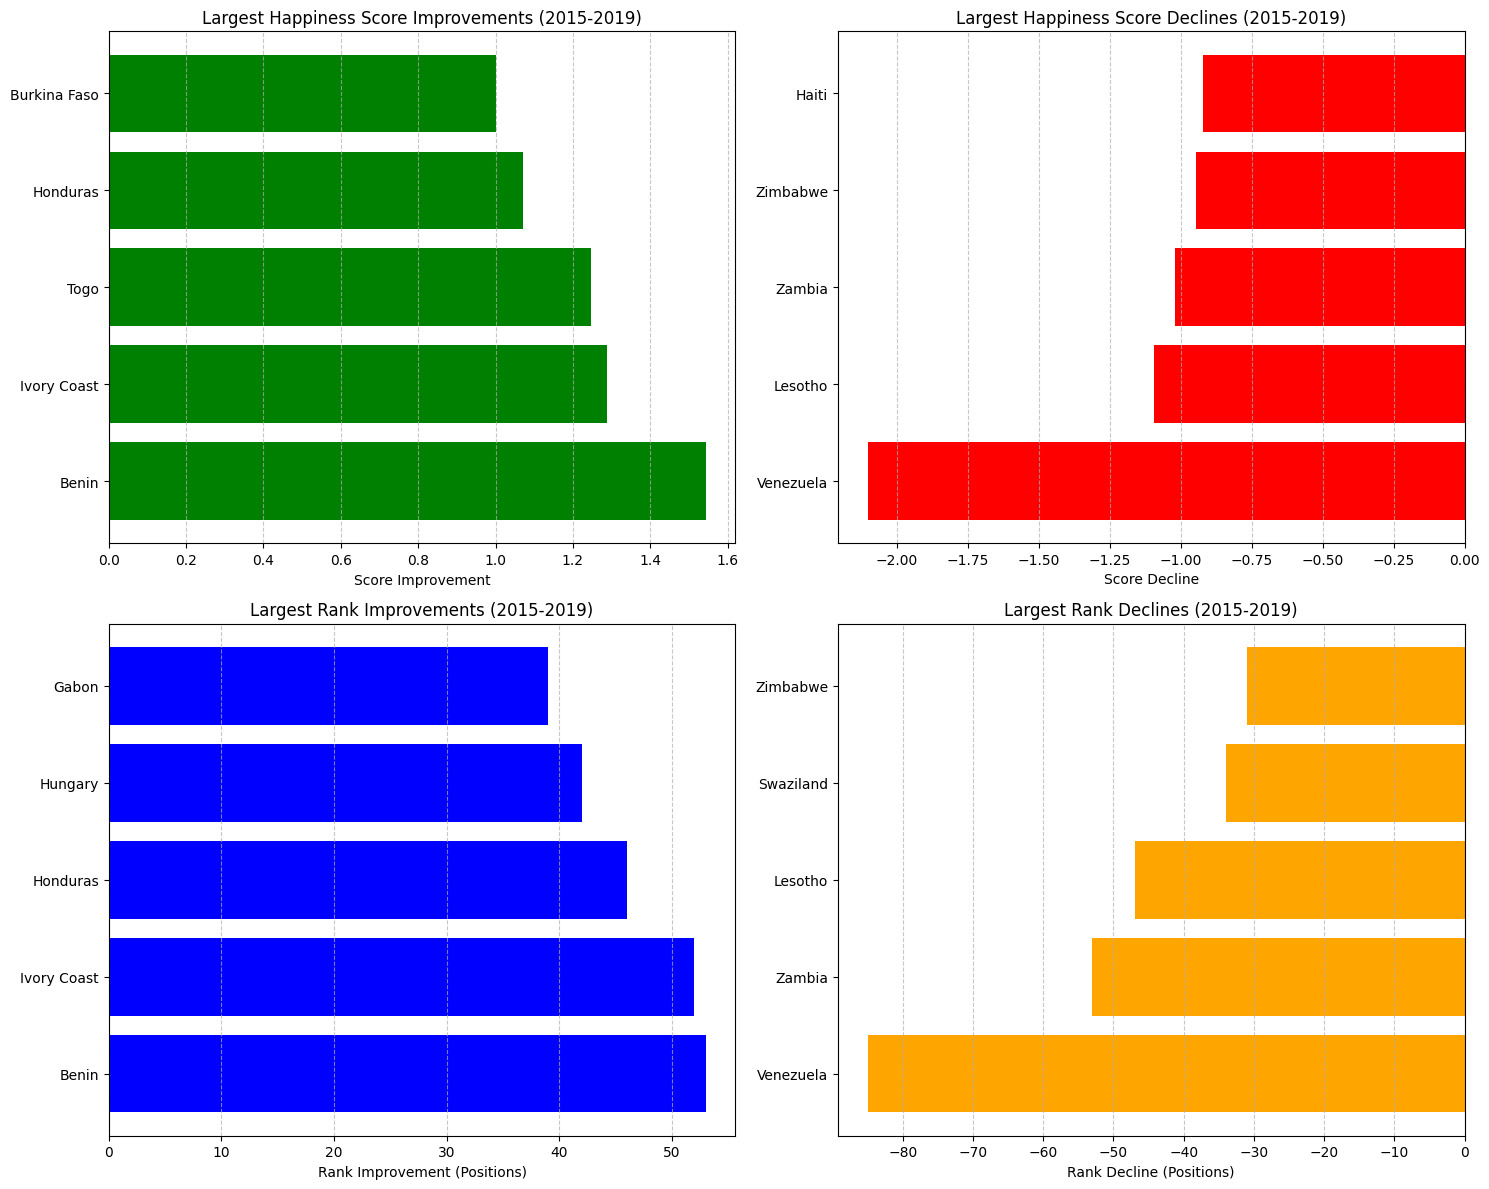

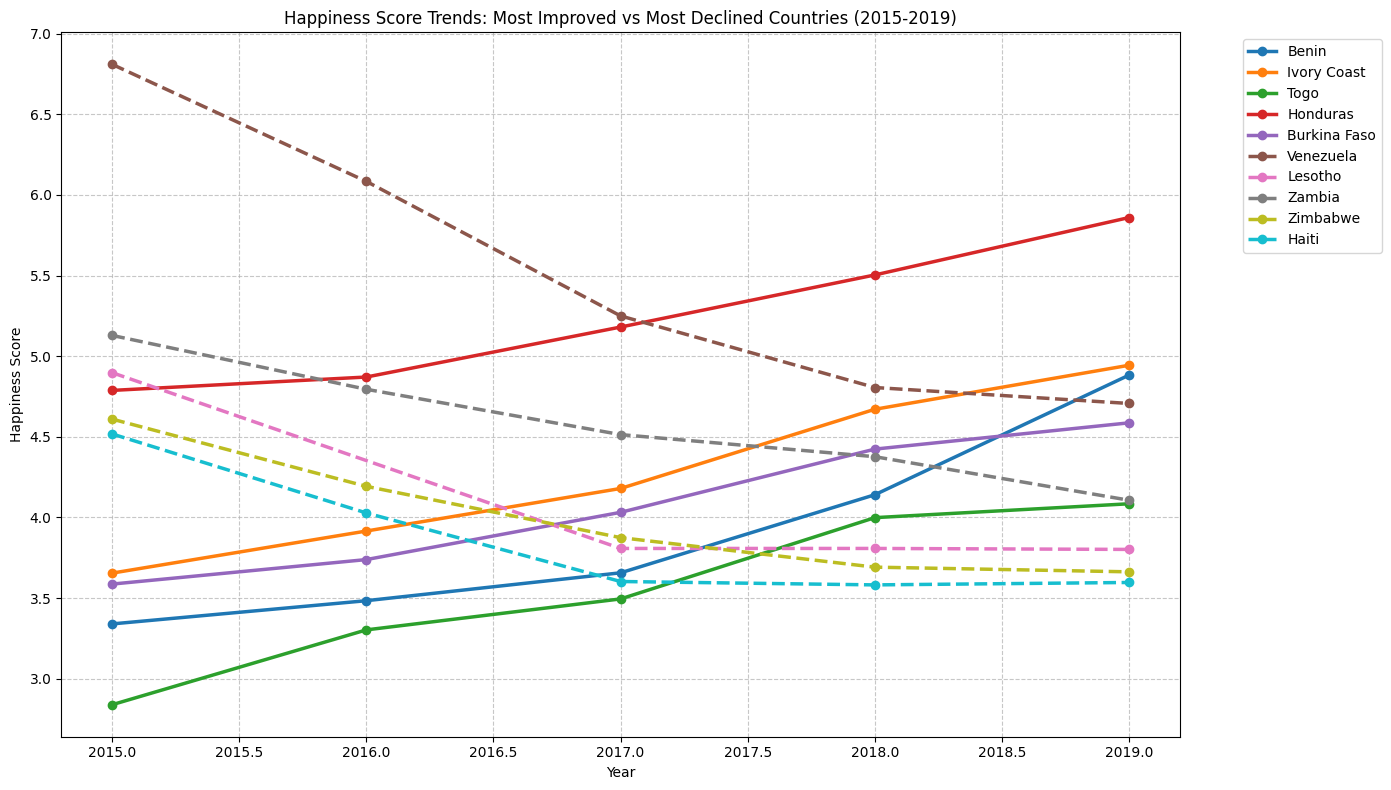

In [ ]:
changes_16_17 = calculate_year_changes(2016, 2017, df_2016, df_2017)
changes_17_18 = calculate_year_changes(2017, 2018, df_2017, df_2018)
changes_18_19 = calculate_year_changes(2018, 2019, df_2018, df_2019)
changes_15_19 = calculate_year_changes(2015, 2019, df_2015, df_2019)
significant_rank_changes_15_19 = changes_15_19[abs(changes_15_19['rank_change']) > 15] # Finds rows where the absolute value of rank change is greater than 15
significant_score_changes_15_19 = changes_15_19[abs(changes_15_19['score_change']) > 0.3] #Finds rows where the absolute value of score change is greater than 0.3

print("COUNTRIES WITH SIGNIFICANT HAPPINESS CHANGES (2015-2019)")
print("=" * 60)

print("Countries with Largest Happiness Improvements (2015-2019):")
print("-" * 55)
top_improvers = significant_score_changes_15_19.nlargest(10, 'score_change')
for _, row in top_improvers.iterrows():
    print(f"{row['country']}: +{row['score_change']:.3f} points "
          f"(from {row['score_2015']:.3f} to {row['score_2019']:.3f})")

print("Countries with Largest Happiness Declines (2015-2019):")
print("-" * 50)
top_decliners = significant_score_changes_15_19.nsmallest(10, 'score_change')
for _, row in top_decliners.iterrows():
    print(f"{row['country']}: {row['score_change']:.3f} points "
          f"(from {row['score_2015']:.3f} to {row['score_2019']:.3f})")

print("Countries with Largest Rank Improvements (2015-2019):")
print("-" * 50)
top_rank_improvers = significant_rank_changes_15_19.nlargest(10, 'rank_change')
for _, row in top_rank_improvers.iterrows():
    print(f"{row['country']}: +{row['rank_change']} positions "
          f"(from #{row['rank_2015']} to #{row['rank_2019']})")

print("Countries with Largest Rank Declines (2015-2019):")
print("-" * 45)
top_rank_decliners = significant_rank_changes_15_19.nsmallest(10, 'rank_change')
for _, row in top_rank_decliners.iterrows():
    print(f"{row['country']}: {row['rank_change']} positions "
          f"(from #{row['rank_2015']} to #{row['rank_2019']})")

# Create visualizations
plt.figure(figsize=(15, 12))

# Plot 1: Countries with largest happiness improvements
plt.subplot(2, 2, 1)
top_5_improvers = significant_score_changes_15_19.nlargest(5, 'score_change')
plt.barh(top_5_improvers['country'], top_5_improvers['score_change'], color='green')
plt.title('Largest Happiness Score Improvements (2015-2019)')
plt.xlabel('Score Improvement')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot 2: Countries with largest happiness declines
plt.subplot(2, 2, 2)
top_5_decliners = significant_score_changes_15_19.nsmallest(5, 'score_change')
plt.barh(top_5_decliners['country'], top_5_decliners['score_change'], color='red')
plt.title('Largest Happiness Score Declines (2015-2019)')
plt.xlabel('Score Decline')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot 3: Countries with largest rank improvements
plt.subplot(2, 2, 3)
top_5_rank_improvers = significant_rank_changes_15_19.nlargest(5, 'rank_change')
plt.barh(top_5_rank_improvers['country'], top_5_rank_improvers['rank_change'], color='blue')
plt.title('Largest Rank Improvements (2015-2019)')
plt.xlabel('Rank Improvement (Positions)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot 4: Countries with largest rank declines
plt.subplot(2, 2, 4)
top_5_rank_decliners = significant_rank_changes_15_19.nsmallest(5, 'rank_change')
plt.barh(top_5_rank_decliners['country'], top_5_rank_decliners['rank_change'], color='orange')
plt.title('Largest Rank Declines (2015-2019)')
plt.xlabel('Rank Decline (Positions)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Create a line plot for the most improved and most declined countries
most_changed_countries = list(top_5_improvers['country']) + list(top_5_decliners['country'])
country_trends = df_combined[df_combined['country'].isin(most_changed_countries)]

plt.figure(figsize=(14, 8))
for country in most_changed_countries:
    country_data = country_trends[country_trends['country'] == country]
    if country in list(top_5_improvers['country']):
        plt.plot(country_data['year'], country_data['score'], marker='o', linewidth=2.5, label=country)
    else:
        plt.plot(country_data['year'], country_data['score'], marker='o', linestyle='--', linewidth=2.5, label=country)

plt.title('Happiness Score Trends: Most Improved vs Most Declined Countries (2015-2019)')
plt.xlabel('Year')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Correlation Matrix of Happiness Factors:


,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,perceptions_of_corruption,generosity
score,1.000000,0.789284,0.648799,0.742456,0.551258,0.398418,0.137578
gdp_per_capita,0.789284,1.000000,0.585966,0.784338,0.340511,0.306307,-0.014560
social_support,0.648799,0.585966,1.000000,0.572650,0.420361,0.126401,-0.037262
healthy_life_expectancy,0.742456,0.784338,0.572650,1.000000,0.340745,0.250512,0.010638
freedom,0.551258,0.340511,0.420361,0.340745,1.000000,0.459593,0.290706
perceptions_of_corruption,0.398418,0.306307,0.126401,0.250512,0.459593,1.000000,0.318920
generosity,0.137578,-0.014560,-0.037262,0.010638,0.290706,0.318920,1.000000


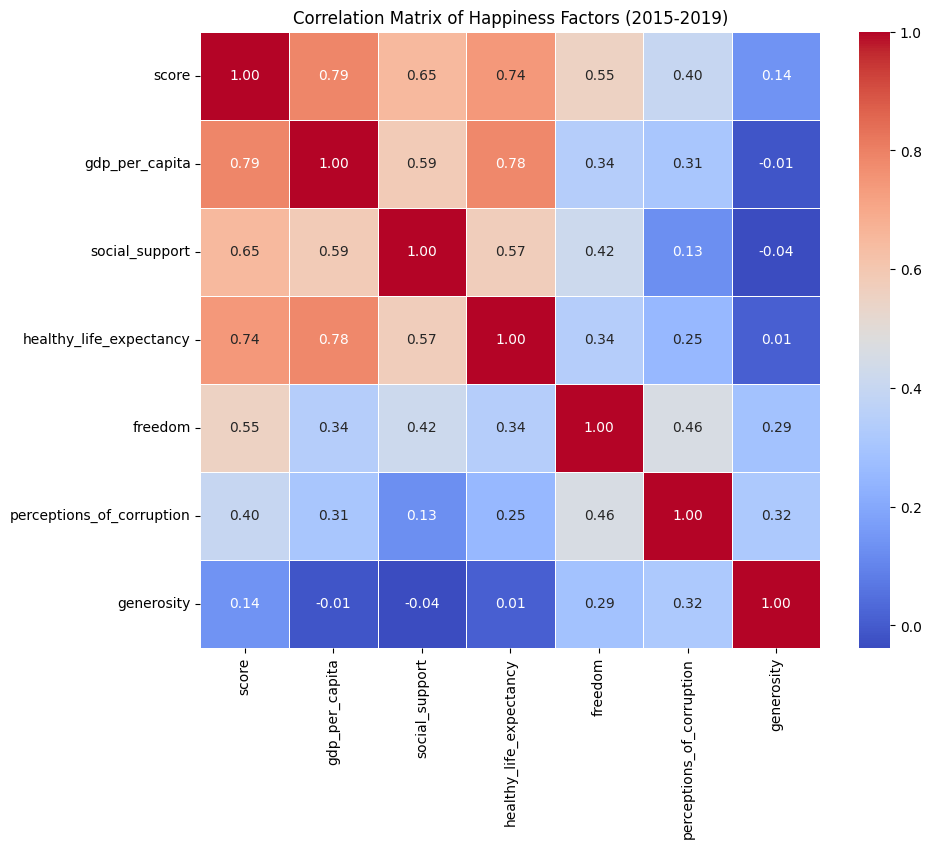

In [ ]:
# Perform correlation analysis on the numerical columns
correlation_matrix = df_combined[numerical_columns].corr()

# Display the correlation matrix
print("\nCorrelation Matrix of Happiness Factors:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Happiness Factors (2015-2019)')
plt.show()

In [ ]:
numerical_factors = ['gdp_per_capita', 'social_support', 'healthy_life_expectancy',
                     'freedom', 'perceptions_of_corruption', 'generosity']

# Group by region and year and calculate the mean for the score and factors
df_regional_averages = df_combined.groupby(['region', 'year'])[['score'] + numerical_factors].mean().reset_index()

display(df_regional_averages.head())

,region,year,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,perceptions_of_corruption,generosity
0,Australia and New Zealand,2015,7.2850,1.291880,1.314450,0.919965,0.645310,0.392795,0.455315
1,Australia and New Zealand,2016,7.3235,1.402545,1.138770,0.841080,0.574920,0.371175,0.484040
2,Australia and New Zealand,2017,7.2990,1.445060,1.529119,0.830323,0.607835,0.342000,0.488852
3,Australia and New Zealand,2018,7.2980,1.304000,1.587000,0.893000,0.658000,0.345500,0.363000
4,Australia and New Zealand,2019,7.2675,1.337500,1.552500,1.031000,0.571000,0.335000,0.331000



 analyzing the trend of happiness score and factor contributions over the years.



In [ ]:
regions = df_regional_averages['region'].unique()

print("Regional Happiness and Factor Trends (2015-2019):\n")

for region in regions:
    print(f"--- Region: {region} ---")
    region_data = df_regional_averages[df_regional_averages['region'] == region].sort_values('year')

    print(f" Happiness Score Trend:")
    for i in range(1, len(region_data)):
        year1 = region_data.iloc[i-1]['year']
        year2 = region_data.iloc[i]['year']
        score1 = region_data.iloc[i-1]['score']
        score2 = region_data.iloc[i]['score']
        score_change = score2 - score1
        print(f"    {year1} to {year2}: Change = {score_change:.3f}")

    print(f" Factor Contribution Trends:")
    for factor in numerical_factors:
        print(f"    {factor}:")
        for i in range(1, len(region_data)):
            year1 = region_data.iloc[i-1]['year']
            year2 = region_data.iloc[i]['year']
            factor1 = region_data.iloc[i-1][factor]
            factor2 = region_data.iloc[i][factor]
            factor_change = factor2 - factor1
            print(f"      {year1} to {year2}: Change = {factor_change:.3f}")
    print("-" * (len(region) + 15))


Regional Happiness and Factor Trends (2015-2019):

--- Region: Australia and New Zealand ---
 Happiness Score Trend:
    2015 to 2016: Change = 0.038
    2016 to 2017: Change = -0.024
    2017 to 2018: Change = -0.001
    2018 to 2019: Change = -0.030
 Factor Contribution Trends:
    gdp_per_capita:
      2015 to 2016: Change = 0.111
      2016 to 2017: Change = 0.043
      2017 to 2018: Change = -0.141
      2018 to 2019: Change = 0.033
    social_support:
      2015 to 2016: Change = -0.176
      2016 to 2017: Change = 0.390
      2017 to 2018: Change = 0.058
      2018 to 2019: Change = -0.034
    healthy_life_expectancy:
      2015 to 2016: Change = -0.079
      2016 to 2017: Change = -0.011
      2017 to 2018: Change = 0.063
      2018 to 2019: Change = 0.138
    freedom:
      2015 to 2016: Change = -0.070
      2016 to 2017: Change = 0.033
      2017 to 2018: Change = 0.050
      2018 to 2019: Change = -0.087
    perceptions_of_corruption:
      2015 to 2016: Change = -0.022
   

#  regional analysis of how happiness and its factors have changed over the years for each region.



In [ ]:
print("--- Regional Trend Summary (2015-2019) ---")
print("-" * 40)

for region in regions:
    print(f"Region: {region}")
    region_data = df_regional_averages[df_regional_averages['region'] == region].sort_values('year')

    # Summarize Happiness Score Trend
    score_start = region_data.iloc[0]['score']
    score_end = region_data.iloc[-1]['score']
    score_total_change = score_end - score_start
    print(f"  Overall Happiness Score Change (2015-2019): {score_total_change:.3f}")
    # Simple observation of yearly changes
    score_changes = region_data['score'].diff().dropna()
    if all(score_changes >= 0):
        print("  Happiness Score Trend: Generally Increasing")
    elif all(score_changes <= 0):
        print("  Happiness Score Trend: Generally Decreasing")
    elif (score_changes > 0).sum() > (score_changes < 0).sum():
        print("  Happiness Score Trend: More periods of Increase")
    elif (score_changes < 0).sum() > (score_changes > 0).sum():
        print("  Happiness Score Trend: More periods of Decrease")
    else:
        print("  Happiness Score Trend: Mixed (Periods of Increase and Decrease)")


    # Summarize Factor Contribution Trends
    print("  Factor Contribution Overall Changes (2015-2019):")
    for factor in numerical_factors:
        factor_start = region_data.iloc[0][factor]
        factor_end = region_data.iloc[-1][factor]
        factor_total_change = factor_end - factor_start
        print(f"    {factor}: {factor_total_change:.3f}")

    print("-" * 40)

--- Regional Trend Summary (2015-2019) ---
----------------------------------------
Region: Australia and New Zealand
  Overall Happiness Score Change (2015-2019): -0.018
  Happiness Score Trend: More periods of Decrease
  Factor Contribution Overall Changes (2015-2019):
    gdp_per_capita: 0.046
    social_support: 0.238
    healthy_life_expectancy: 0.111
    freedom: -0.074
    perceptions_of_corruption: -0.058
    generosity: -0.124
----------------------------------------
Region: Central and Eastern Europe
  Overall Happiness Score Change (2015-2019): 0.239
  Happiness Score Trend: Generally Increasing
  Factor Contribution Overall Changes (2015-2019):
    gdp_per_capita: 0.080
    social_support: 0.287
    healthy_life_expectancy: 0.090
    freedom: -0.000
    perceptions_of_corruption: -0.024
    generosity: -0.011
----------------------------------------
Region: Eastern Asia
  Overall Happiness Score Change (2015-2019): 0.063
  Happiness Score Trend: Mixed (Periods of Increase a

In [ ]:
# Calculating overall average happiness score and factor contributions for each region
df_regional_overall_averages = df_combined.groupby('region')[['score'] + numerical_factors].mean().reset_index()

# Sort regions by overall average happiness score in descending order
df_regional_overall_averages_sorted_score = df_regional_overall_averages.sort_values('score', ascending=False)

print("Overall Average Happiness Score and Factor Contributions by Region (2015-2019):")
display(df_regional_overall_averages_sorted_score)

# Sort regions by overall average contribution for each factor in descending order
print("Regional Rankings by Overall Average Factor Contribution (2015-2019):")
for factor in numerical_factors:
    print(f"--- {factor.replace('_', ' ').title()} ---")
    df_sorted_factor = df_regional_overall_averages.sort_values(factor, ascending=False)[['region', factor]]
    display(df_sorted_factor)

Overall Average Happiness Score and Factor Contributions by Region (2015-2019):


,region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,perceptions_of_corruption,generosity
0,Australia and New Zealand,7.294600,1.356197,1.424368,0.903074,0.611413,0.357294,0.424441
5,North America,7.174700,1.422037,1.357991,0.861086,0.558918,0.223345,0.372339
9,Western Europe,6.759311,1.372702,1.338851,0.892661,0.516868,0.223788,0.271988
3,Latin America and Caribbean,6.020725,0.936425,1.181575,0.676763,0.463089,0.093807,0.185513
2,Eastern Asia,5.630464,1.219484,1.190343,0.862189,0.417611,0.113642,0.191472
1,Central and Eastern Europe,5.428875,1.018734,1.171523,0.695550,0.352283,0.075969,0.156806
4,Middle East and Northern Africa,5.337208,1.102633,0.993466,0.665565,0.348679,0.144670,0.178271
6,Southeastern Asia,5.335227,0.893340,1.093673,0.635452,0.543723,0.136140,0.384195
7,Southern Asia,4.580657,0.638813,0.803835,0.513089,0.392867,0.100357,0.300888
8,Sub-Saharan Africa,4.188482,0.448843,0.845211,0.283140,0.353492,0.105672,0.207277


Regional Rankings by Overall Average Factor Contribution (2015-2019):
--- Gdp Per Capita ---


,region,gdp_per_capita
5,North America,1.422037
9,Western Europe,1.372702
0,Australia and New Zealand,1.356197
2,Eastern Asia,1.219484
4,Middle East and Northern Africa,1.102633
1,Central and Eastern Europe,1.018734
3,Latin America and Caribbean,0.936425
6,Southeastern Asia,0.893340
7,Southern Asia,0.638813
8,Sub-Saharan Africa,0.448843


--- Social Support ---


...

,region,freedom
0,Australia and New Zealand,0.611413
5,North America,0.558918
6,Southeastern Asia,0.543723
9,Western Europe,0.516868
3,Latin America and Caribbean,0.463089
2,Eastern Asia,0.417611
7,Southern Asia,0.392867
8,Sub-Saharan Africa,0.353492
1,Central and Eastern Europe,0.352283
4,Middle East and Northern Africa,0.348679


--- Perceptions Of Corruption ---


,region,perceptions_of_corruption
0,Australia and New Zealand,0.357294
9,Western Europe,0.223788
5,North America,0.223345
4,Middle East and Northern Africa,0.144670
6,Southeastern Asia,0.136140
2,Eastern Asia,0.113642
8,Sub-Saharan Africa,0.105672
7,Southern Asia,0.100357
3,Latin America and Caribbean,0.093807
1,Central and Eastern Europe,0.075969


--- Generosity ---


,region,generosity
0,Australia and New Zealand,0.424441
6,Southeastern Asia,0.384195
5,North America,0.372339
7,Southern Asia,0.300888
9,Western Europe,0.271988
8,Sub-Saharan Africa,0.207277
2,Eastern Asia,0.191472
3,Latin America and Caribbean,0.185513
4,Middle East and Northern Africa,0.178271
1,Central and Eastern Europe,0.156806


## Visuals for regional data




/tmp/ipython-input-208642955.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='region', data=df_regional_overall_averages_sorted_score, palette='viridis')


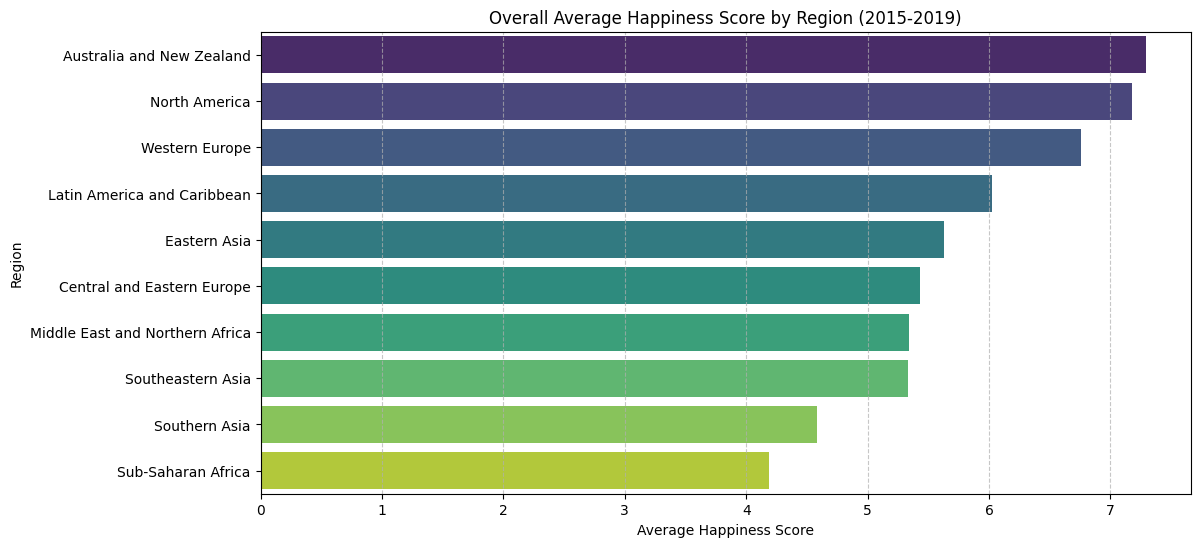

/tmp/ipython-input-208642955.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=factor, y='region', data=df_sorted_factor, ax=axes[i], palette='viridis')
/tmp/ipython-input-208642955.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=factor, y='region', data=df_sorted_factor, ax=axes[i], palette='viridis')
/tmp/ipython-input-208642955.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=factor, y='region', data=df_sorted_factor, ax=axes[i], palette='viridis')
/tmp/ipython-input-208642955.py:17: FutureWarning: 

Passing `palette` wi

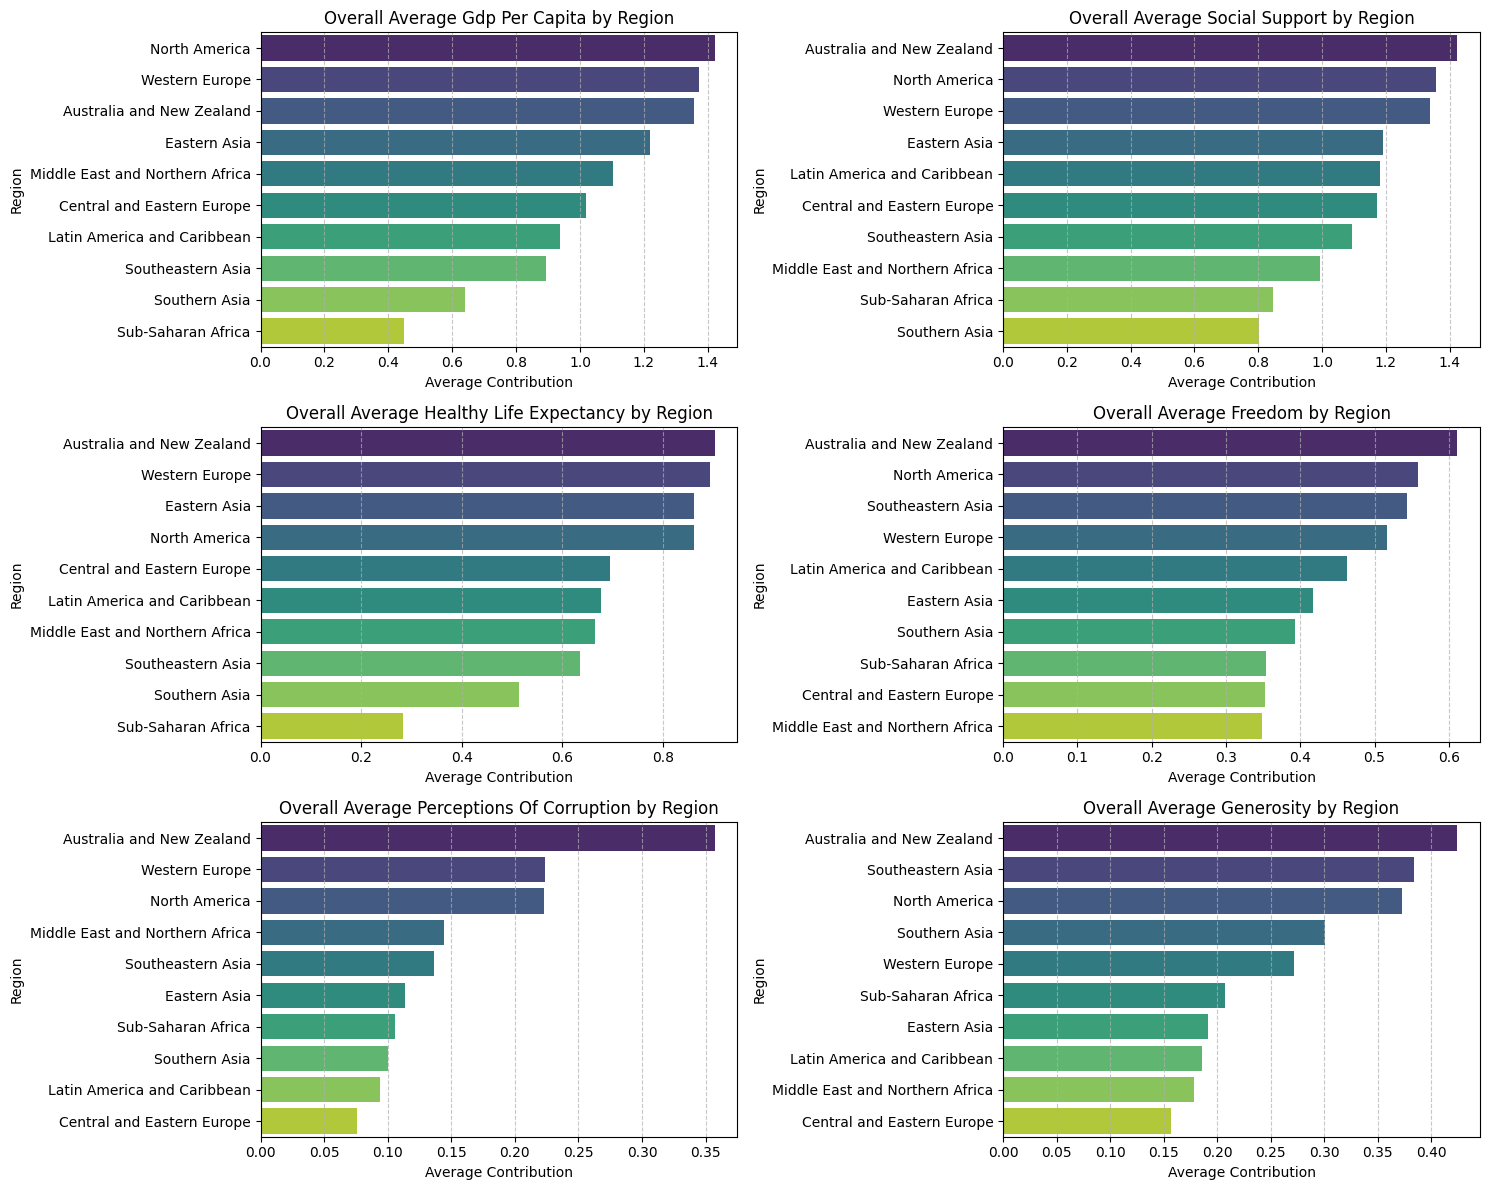

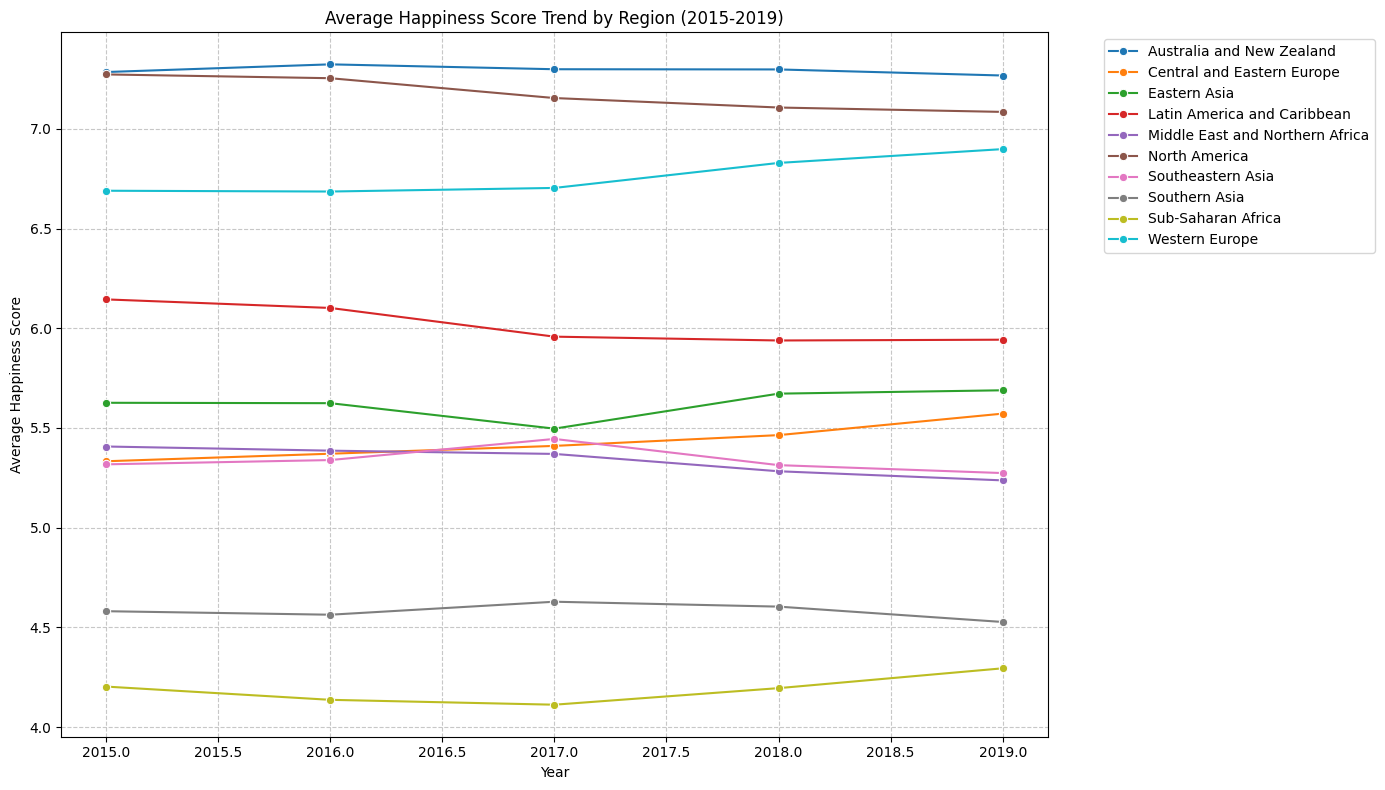

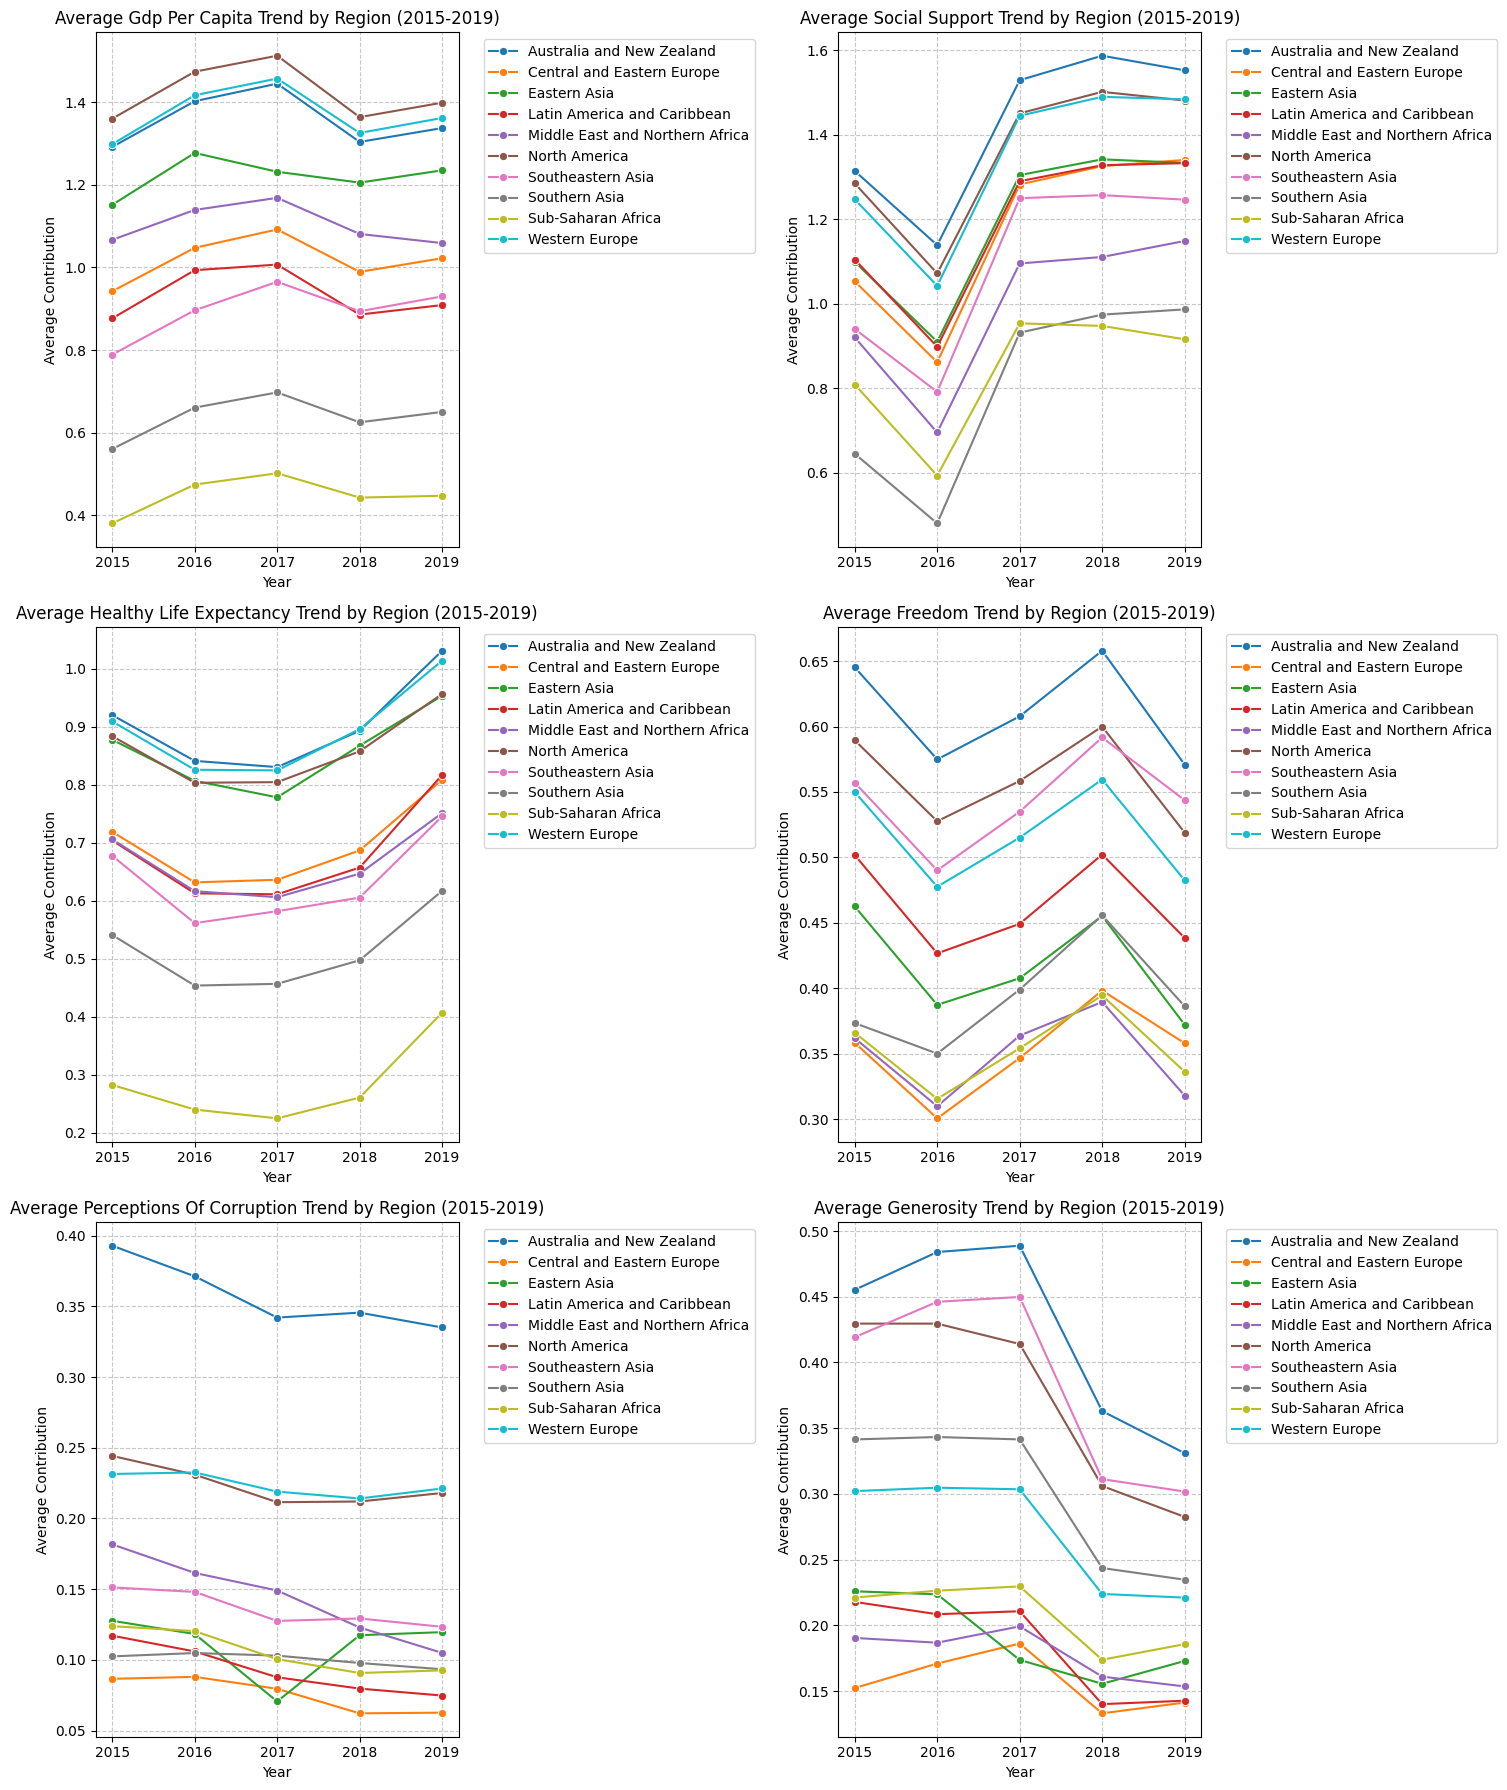

In [ ]:
# 1. Bar plot for overall average happiness score by region
plt.figure(figsize=(12, 6))
sns.barplot(x='score', y='region', data=df_regional_overall_averages_sorted_score, palette='viridis')
plt.title('Overall Average Happiness Score by Region (2015-2019)')
plt.xlabel('Average Happiness Score')
plt.ylabel('Region')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 2. Bar plots for overall average contribution of each numerical factor by region
n_factors = len(numerical_factors)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, n_factors * 2))
axes = axes.flatten()

for i, factor in enumerate(numerical_factors):
    df_sorted_factor = df_regional_overall_averages.sort_values(factor, ascending=False)
    sns.barplot(x=factor, y='region', data=df_sorted_factor, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Overall Average {factor.replace("_", " ").title()} by Region')
    axes[i].set_xlabel('Average Contribution')
    axes[i].set_ylabel('Region')
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 3. Line plot for the trend of average happiness score over the years by region
plt.figure(figsize=(14, 8))
sns.lineplot(data=df_regional_averages, x='year', y='score', hue='region', marker='o')
plt.title('Average Happiness Score Trend by Region (2015-2019)')
plt.xlabel('Year')
plt.ylabel('Average Happiness Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Line plots for the trend of the average contribution of each numerical factor over the years by region
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, n_factors * 3))
axes = axes.flatten()

for i, factor in enumerate(numerical_factors):
    sns.lineplot(data=df_regional_averages, x='year', y=factor, hue='region', marker='o', ax=axes[i])
    axes[i].set_title(f'Average {factor.replace("_", " ").title()} Trend by Region (2015-2019)')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Average Contribution')
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

/tmp/ipython-input-461010448.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


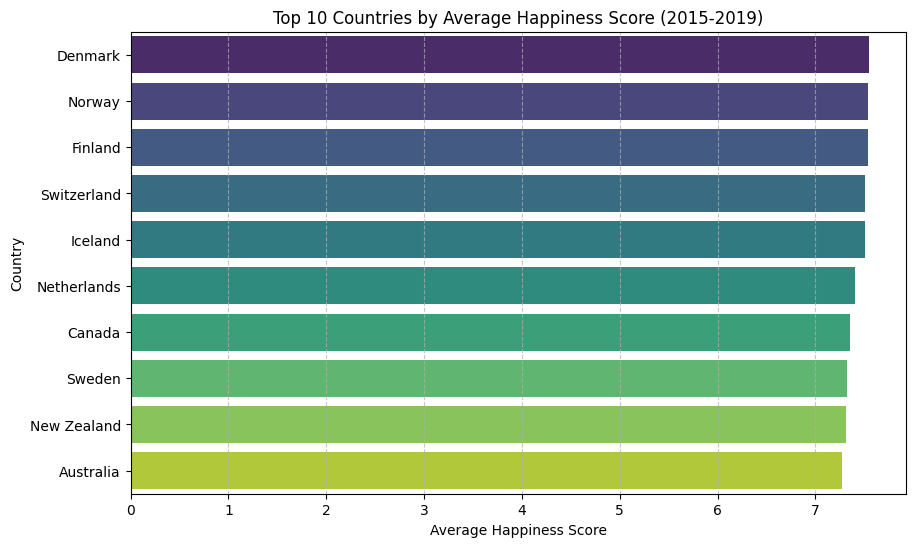

/tmp/ipython-input-461010448.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rank_countries.values, y=top_rank_countries.index, palette='viridis')


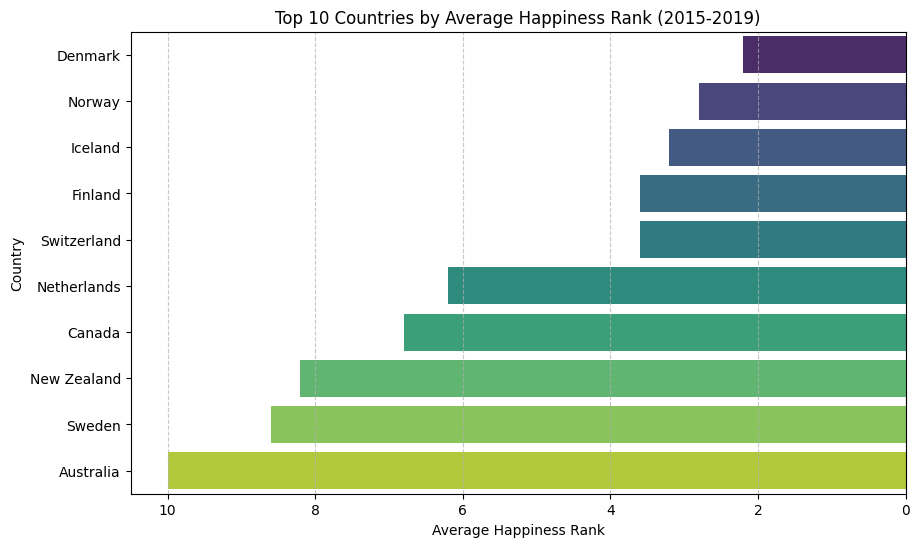

In [ ]:


# Visualize the top 10 countries by average happiness score
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Average Happiness Score (2015-2019)')
plt.xlabel('Average Happiness Score')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# To visualize by rank, we need the average rank.
# Calculate the average rank for each country
average_rank = df_combined.groupby('country')['rank'].mean().sort_values()

top_rank_countries = average_rank.head(10)

# top 10 countries by average rank
plt.figure(figsize=(10, 6))
sns.barplot(x=top_rank_countries.values, y=top_rank_countries.index, palette='viridis')
plt.title('Top 10 Countries by Average Happiness Rank (2015-2019)')
plt.xlabel('Average Happiness Rank')
plt.ylabel('Country')
plt.gca().invert_xaxis() # Inverts the x-axis so rank 1 is at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Problem Statement:Build a model that can determine happiness based on the provided features